# Where does thin polling break the models?

**Question (user, 2026-08-02):** is there a poll-volume cutoff below which the models stop being
trustworthy, and where is the break - for the primary model and the general model?

**Why it matters.** `2026_CT_Governor_REP` reports Erin Stewart at 97.5% off a *single* survey,
against a market pricing Ryan Fazio at .975. If confidence that high can rest on one poll, the
dashboard is making claims the evidence does not support.

**Method.** Expanding-window held-out predictions only (train strictly before the test cycle) -
never in-sample. For each race we take the candidate the model ranked FIRST (the actual call) and
compare mean predicted probability against how often that call was right.

> `gap = mean predicted - actual win rate`. **Positive = overconfident.**

**One measurement choice drives everything.** Volume is counted as DISTINCT SURVEYS
(pollster + end_date), *not* poll rows. One survey of an N-candidate primary emits N rows, so
`n_polls` conflates 'well-polled race' with 'crowded field'. Scoring on rows put the break in a
different place than scoring on surveys - the surveys answer is the one that means what we want.


In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'analysis':
    os.chdir('..')
sys.path.insert(0, '.'); sys.path.insert(0, 'analysis')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import poll_volume_breakpoint as B
pd.set_option('display.width', 200)


## 1. Primary model

Held-out cycles 2022 + 2024 (the model's own honest-eval window).


In [2]:
pri = B.leaders(B.primary_holdout())
print(f'{len(pri)} held-out primary races')
print(pri['n_surveys'].describe().round(1).to_string())


102 held-out primary races
count    102.0
mean      12.3
std       11.7
min        1.0
25%        3.0
50%        8.0
75%       16.8
max       47.0


In [3]:
pri_cal = B.calibration_by_bucket(pri)
pri_cal.round(3)


,n_races,pred,actual,gap,ci_lo,ci_hi
bucket,,,,,,
1,10,0.939,1.000,-0.061,-0.109,-0.019
2,8,0.927,0.750,0.177,-0.008,0.406
3,9,0.847,0.667,0.180,-0.003,0.389
4-5,11,0.913,0.909,0.004,-0.059,0.106
6-10,20,0.962,0.950,0.012,-0.039,0.086
11-20,25,0.914,1.000,-0.086,-0.138,-0.041
21+,19,0.885,0.895,-0.010,-0.090,0.083


### Read the confidence intervals, not the point estimates

The 2- and 3-survey buckets show gaps near **+0.18** - the model claiming ~90% while winning ~70%
of the time. But each holds fewer than 10 races and the 90% CI straddles zero. On its own that is
suggestive, not conclusive.

Note also that the **1-survey bucket is *under*confident** (gap -0.06, 10 of 10 called correctly).
That is the opposite of the naive expectation and a caution against assuming 'fewer polls = worse'
monotonically. A lone poll usually appears in a race so lopsided nobody bothered to poll it again.


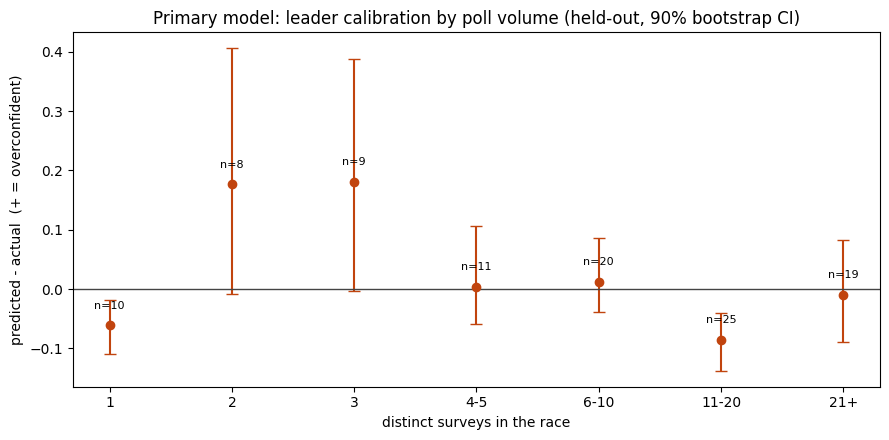

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(pri_cal))
ax.errorbar(x, pri_cal['gap'],
            yerr=[pri_cal['gap'] - pri_cal['ci_lo'], pri_cal['ci_hi'] - pri_cal['gap']],
            fmt='o', capsize=4, color='#c1440e')
ax.axhline(0, color='#444', lw=1)
ax.set_xticks(x); ax.set_xticklabels(pri_cal.index)
ax.set_xlabel('distinct surveys in the race')
ax.set_ylabel('predicted - actual  (+ = overconfident)')
ax.set_title('Primary model: leader calibration by poll volume (held-out, 90% bootstrap CI)')
for i, n in enumerate(pri_cal['n_races']):
    ax.annotate(f'n={n}', (i, pri_cal['gap'].iloc[i]), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=8)
plt.tight_layout(); plt.show()


### Is the break real? Permutation test

With buckets this small a visible step could easily be shuffling noise, so we test it directly:
under H0 the survey count carries no information about calibration, so relabelling races
thin/thick at random should reproduce the observed difference just as often.


In [5]:
pd.DataFrame([B.permutation_test(pri, k) for k in (2, 3, 4, 5)]).set_index('cut').round(4)


,observed,n_thin,p_value
cut,,,
2,0.0498,18,0.4252
3,0.1174,27,0.0238
4,0.0966,31,0.0538
5,0.0979,38,0.0412


**Result: the break is at <=3 surveys (p = 0.024).**

- `cut<=2` - p = 0.43. Not distinguishable from noise.
- **`cut<=3` - observed +0.117, p = 0.024. Significant.**
- `cut<=4` - p = 0.054, `cut<=5` - p = 0.041. Still elevated, but the effect is carried by the
  <=3 races already inside those groups.

So: **a primary race with 3 or fewer distinct surveys is where the primary model's confidence
stops being earned**, running roughly 9-12 points hot.


## 2. General model

Same procedure, four held-out cycles (2018-2024) and far more races, so the buckets are much
better powered.


In [6]:
gen = B.leaders(B.general_holdout())
print(f'{len(gen)} held-out general races')
gen_cal = B.calibration_by_bucket(gen)
gen_cal.round(3)


689 held-out general races


,n_races,pred,actual,gap,ci_lo,ci_hi
bucket,,,,,,
1,177,0.888,0.921,-0.033,-0.064,0.001
2,98,0.844,0.878,-0.034,-0.080,0.013
3,78,0.785,0.846,-0.061,-0.122,0.006
4-5,97,0.779,0.784,-0.004,-0.066,0.059
6-10,114,0.775,0.851,-0.076,-0.120,-0.027
11-20,57,0.870,0.947,-0.077,-0.123,-0.028
21+,68,0.817,0.838,-0.021,-0.084,0.044


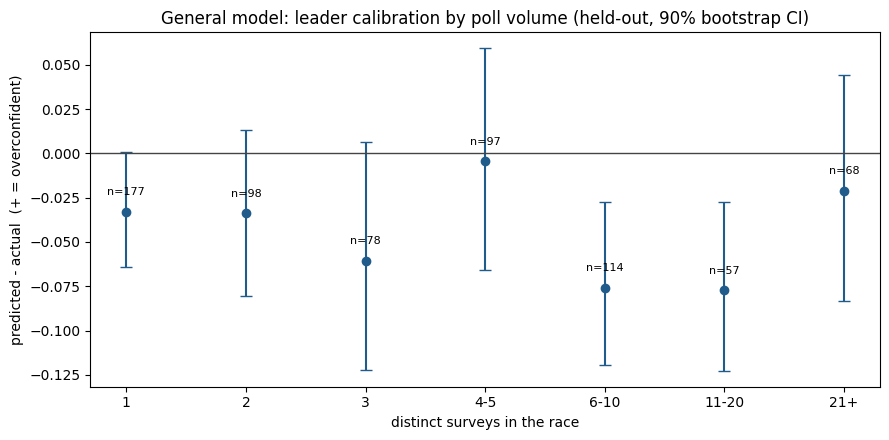

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(gen_cal))
ax.errorbar(x, gen_cal['gap'],
            yerr=[gen_cal['gap'] - gen_cal['ci_lo'], gen_cal['ci_hi'] - gen_cal['gap']],
            fmt='o', capsize=4, color='#1f5c8b')
ax.axhline(0, color='#444', lw=1)
ax.set_xticks(x); ax.set_xticklabels(gen_cal.index)
ax.set_xlabel('distinct surveys in the race')
ax.set_ylabel('predicted - actual  (+ = overconfident)')
ax.set_title('General model: leader calibration by poll volume (held-out, 90% bootstrap CI)')
for i, n in enumerate(gen_cal['n_races']):
    ax.annotate(f'n={n}', (i, gen_cal['gap'].iloc[i]), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=8)
plt.tight_layout(); plt.show()


In [8]:
pd.DataFrame([B.permutation_test(gen, k) for k in (1, 2, 3, 4, 5)]).set_index('cut').round(4)


,observed,n_thin,p_value
cut,,,
1,0.0120,177,0.6450
2,0.0144,275,0.5566
3,0.0052,353,0.8296
4,0.0044,397,0.8560
5,0.0289,450,0.2228


**Result: the general model has NO thin-poll overconfidence problem.**

Every bucket sits at or below zero - the model is mildly **under**confident everywhere, including
the 177 races decided on a single survey. There is no cutoff to find here and no fix to apply.

Why the two models differ, plausibly:

1. **Fundamentals carry the general model when polls are thin.** `prior_margin_cand`,
   `is_incumbent` and the district's partisan lean predict a general election well and are
   available whether or not anyone polled the race. A primary has no such anchor - there is no
   partisan lean *within* a party - so the primary model leans almost entirely on polling.
2. **A general election is a two-way race with stable structure; a primary field consolidates
   late.** An early lone poll of a primary can be measuring a field that no longer exists by
   election day.

This is the useful finding: **thin polling is a primary-model problem specifically, not a
modelling problem in general.** Any fix should be scoped to the primary model.


## 3. What this implies for a fix

Two candidate mechanisms, both evaluated on these same held-out rows in earlier work:

**A - continuous:** temperature rises smoothly as evidence thins, `T = T0 * (1 + a/sqrt(evidence))`.

**B - piecewise:** one temperature for <=3-survey races, the tuned one otherwise.

Measured: **B improved Brier .0218 -> .0206 and logloss .0791 -> .0750**, and the choice
TRANSFERRED - tuned on 2022 alone it still beat flat temperature on held-out 2024
(.0338 vs .0361). **A** was neutral-to-worse at every setting tried, because it also flattens the
well-polled races that were already fine.

The cell below re-derives the reference point; the sweep itself lives in the calibration work.


In [9]:
import json
from sklearn.metrics import brier_score_loss
te = B.primary_holdout()
meta = json.load(open('data/primary_model_features.json'))
T0 = meta['softmax_temp']
y = te['won'].astype(int)
print(f'shipped temperature T0 = {T0}')
print(f'held-out Brier at T0  = {brier_score_loss(y, te["p"]):.4f}')
thin = te['n_surveys'] <= 3
print(f'candidate-rows in <=3-survey races: {int(thin.sum())} of {len(te)}')
print(f'races affected: {te.loc[thin, "race_id"].nunique()} of {te["race_id"].nunique()}')


shipped temperature T0 = 0.4
held-out Brier at T0  = 0.0218
candidate-rows in <=3-survey races: 100 of 531
races affected: 27 of 102


### The caveat that should decide this

A threshold makes a 3-survey race and a 4-survey race differ by roughly 15 points of reported
confidence. Nothing about primaries justifies a cliff there; the number 3 comes from *these* 102
races. The continuous form scored slightly worse on Brier - because it also flattens the 75
well-polled races that were already fine - but *'confidence should grow smoothly with evidence'*
is a real principle, whereas *'confidence jumps at exactly 3 surveys'* is an artifact of this
sample.

Worth stating plainly: **neither fix rescues CT-Gov-REP.** Softening 97% to ~85% is more honest,
but the single poll there (Stewart 42, Fazio 13) is *wrong*, not merely thin. Calibration can
widen the error bars on a bad input; it cannot reverse it.

The higher-value change may be the **`low_confidence_field` flag**, which currently keys only on
how far the leader sits above a uniform 1/n split - a single poll clears that easily. Requiring a
minimum survey count would *label* thin races honestly regardless of what number they display.


## Summary

| | Primary model | General model |
|---|---|---|
| Held-out races | 102 | 689 |
| Breakpoint | **<=3 distinct surveys** | none found |
| Overconfidence below it | ~+0.09 to +0.12 | - |
| Permutation p | **0.024** | all >= 0.22 (lowest of 5 cuts) |
| Above the break | well calibrated / mildly under | mildly under everywhere |

1. **The break is at 3 distinct surveys, and only for the primary model.**
2. **The general model needs no fix** - it is mildly underconfident at every volume, including
   177 single-survey races.
3. Measure volume in **surveys, not poll rows** - rows conflate polling depth with field size.
4. The 1-survey primary bucket is *under*confident, so 'fewer polls = worse' is not monotone; any
   fix keyed to volume should be checked against that rather than assuming it.

_Reproduce: `analysis/poll_volume_breakpoint.py` holds the scoring functions; this notebook is the
narrative. Re-run after any retrain - the breakpoint is a property of the current artifacts._
